In [1]:
import pandas as pd

df = pd.read_excel("../data/Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [8]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [12]:
df["Churn Label"].value_counts()


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [14]:
for col in ["Country", "State", "Count"]:
    print(col)
    print(df[col].value_counts())
    print()

Country
Country
United States    7043
Name: count, dtype: int64

State
State
California    7043
Name: count, dtype: int64

Count
Count
1    7043
Name: count, dtype: int64



In [15]:
df_model = df.drop(
    columns=[
        "CustomerID",
        "Count",
        "Country",
        "State",
        "Lat Long",
        "Churn Value",
        "Churn Score",
        "Churn Reason"
    ]
)

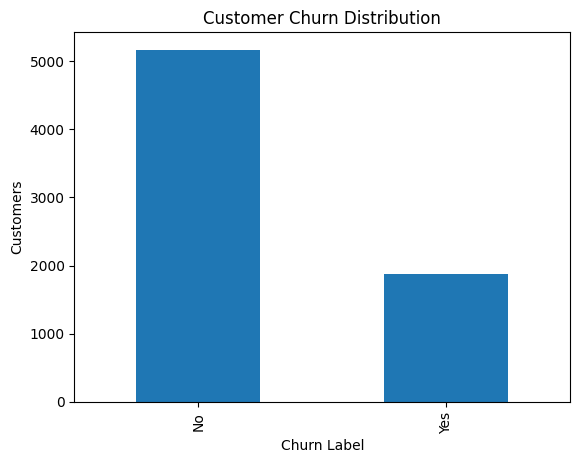

In [16]:
import matplotlib.pyplot as plt

df["Churn Label"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.ylabel("Customers")
plt.show()

In [17]:
df.groupby("Contract")["Churn Value"].mean().sort_values()

Contract
Two year          0.028319
One year          0.112695
Month-to-month    0.427097
Name: Churn Value, dtype: float64

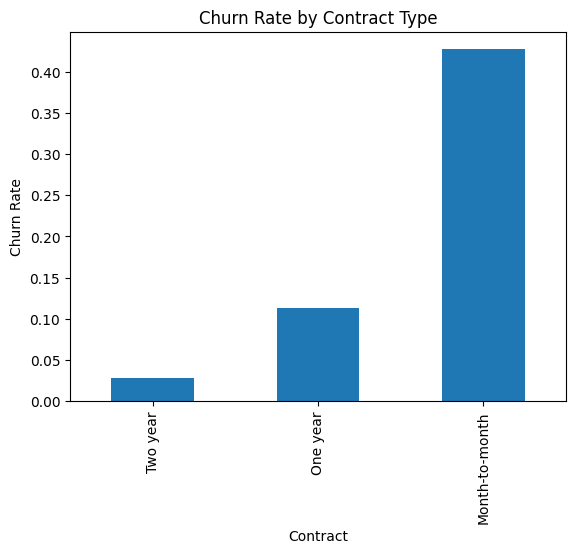

In [18]:
import matplotlib.pyplot as plt

contract_churn = (
    df.groupby("Contract")["Churn Value"]
      .mean()
      .sort_values()
)

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

## Contract Type vs Churn

Contract duration is one of the strongest drivers of churn.

| Contract Type | Churn Rate |
|--------------|------------|
| Two Year | 2.8% |
| One Year | 11.3% |
| Month-to-Month | 42.7% |

Customers with month-to-month contracts are substantially more likely to leave the company than customers with longer-term contracts.

Business Recommendation:
- Encourage customers to move to longer-term contracts through discounts or loyalty programs.

In [20]:
df.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

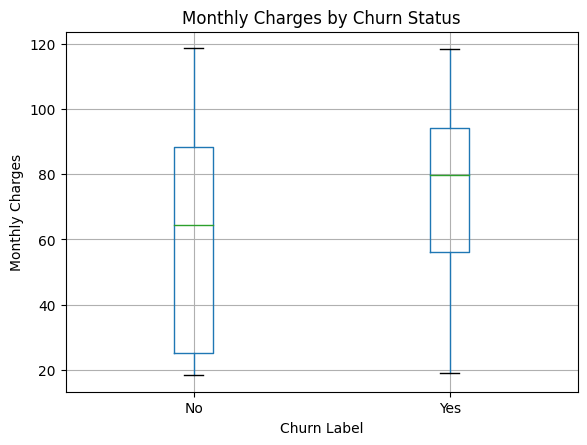

In [ ]:

import matplotlib.pyplot as plt

df.boxplot(column="Monthly Charges", by="Churn Label")

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.ylabel("Monthly Charges")
plt.show()

## Monthly Charges vs Churn

Customers who churn have significantly higher monthly charges.

| Churn Status | Average Monthly Charge |
|-------------|------------------------|
| No Churn | $61.27 |
| Churn | $74.44 |

The boxplot indicates that churned customers generally pay more per month than retained customers.

Business Recommendation:
- Offer retention discounts to high-paying customers.
- Review pricing competitiveness.
- Monitor customer satisfaction among premium subscribers.

In [21]:
df.groupby("Churn Label")["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

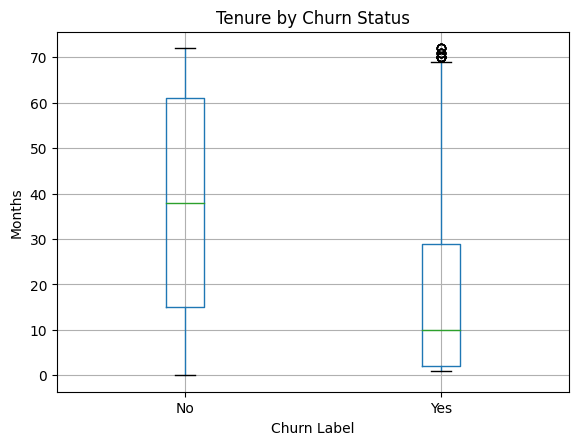

In [22]:
df.boxplot(column="Tenure Months", by="Churn Label")

plt.title("Tenure by Churn Status")
plt.suptitle("")
plt.ylabel("Months")
plt.show()

## Tenure vs Churn

Customer tenure is strongly associated with churn.

| Churn Status | Average Tenure |
|-------------|----------------|
| No Churn | 37.6 months |
| Churn | 18.0 months |

Customers who churn have, on average, less than half the tenure of retained customers.

Business Recommendation:
- Focus retention efforts on new customers during their first year.
- Implement onboarding programs and loyalty incentives.
- Monitor early warning signs of dissatisfaction among recent customers.

In [23]:
df.groupby("Internet Service")["Churn Value"].mean().sort_values()

Internet Service
No             0.074050
DSL            0.189591
Fiber optic    0.418928
Name: Churn Value, dtype: float64

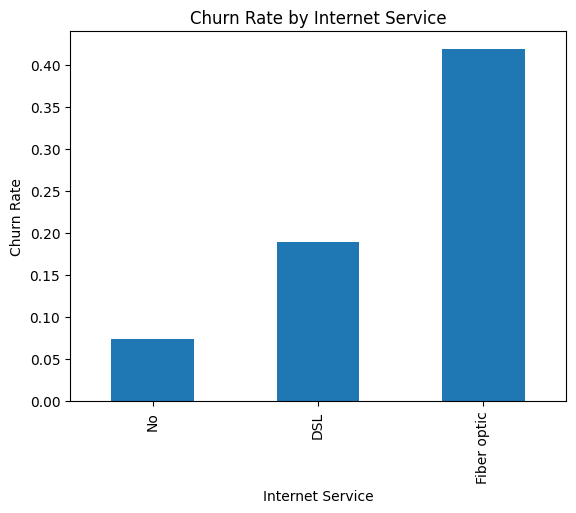

In [24]:
internet_churn = (
    df.groupby("Internet Service")["Churn Value"]
      .mean()
      .sort_values()
)

internet_churn.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate")
plt.show()

## Internet Service vs Churn

Churn rates vary significantly across internet service types.

| Internet Service | Churn Rate |
|-----------------|------------|
| No Internet | 7.4% |
| DSL | 19.0% |
| Fiber Optic | 41.9% |

Fiber optic customers exhibit the highest churn rate despite subscribing to a premium service.

Business Recommendation:
- Investigate customer satisfaction among fiber optic subscribers.
- Review pricing competitiveness.
- Target fiber customers with retention campaigns and loyalty incentives.